In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
from environment import MultiAssetTradingEnv
from stable_baselines3 import PPO

start = "2004-01-01"
end = "2022-12-31"
curr_date = "2025-07-25"

def download_data(tickers, start=start, end=end):
    data_dict = {}
    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.droplevel(1)
        df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
        tick = yf.Ticker(ticker)
        dividends = tick.dividends
        dividends = dividends.rename('Dividends')
        dividends.index = dividends.index.date
        dividends.index = pd.to_datetime(dividends.index)
        final_df = df.join(dividends, how='left')
        final_df['Dividends'] = final_df['Dividends'].fillna(0.0)
        data_dict[ticker] = final_df
    return data_dict

tickers = ["TIP", "SHY", "IEF", "TLT", "AGG", "EEM", "EFA", "SPY", "QQQ", "DIA"]
data_dict = download_data(tickers)

for key, df in data_dict.items():
    print(f"{key}")
    print(df.head())
    print(df.shape[0])
    print(df.isna().any(axis=1).sum())

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

TIP
                 Open       High        Low      Close  Volume  Dividends
Date                                                                     
2004-01-02  51.783004  51.854428  51.629949  51.777901  106900        0.0
2004-01-05  51.604459  51.706493  51.568747  51.706493  115700        0.0
2004-01-06  51.828927  52.063612  51.808523  52.038101  114000        0.0
2004-01-07  51.987102  52.155461  51.946286  52.078934  101700        0.0
2004-01-08  51.966665  52.078905  51.721779  51.879936  132100        0.0
4783
0
SHY
                 Open       High        Low      Close  Volume  Dividends
Date                                                                     
2004-01-02  55.485999  55.485999  55.371479  55.418633  142700        0.0
2004-01-05  55.405146  55.425354  55.371463  55.425354  272400        0.0
2004-01-06  55.432136  55.526443  55.432136  55.492760  243500        0.0
2004-01-07  55.506231  55.553384  55.486023  55.533176  115400        0.0
2004-01-08  55.519732  

In [29]:
# Example usage functions
    # Example usage - Replace with your own data loading
    # Your data should be a dictionary like: {'AAPL': df1, 'MSFT': df2, 'GOOGL': df3}
    # where each DataFrame has columns: ['Open', 'High', 'Low', 'Close', 'Volume']
    
    # Example of how to use with your own data:
    # your_data = {
    #     'AAPL': pd.read_csv('aapl_data.csv'),
    #     'MSFT': pd.read_csv('msft_data.csv'),
    #     'GOOGL': pd.read_csv('googl_data.csv')
    # }
    
    # env = MultiAssetTradingEnv(
    #     data=your_data,
    #     initial_balance=100000,
    #     lookback_window=20
    # )
    
    # print("Environment class is ready. Load your OHLCV data and create the environment instance.")
    # print("Expected data format:")
    # print("data = {'ASSET1': DataFrame, 'ASSET2': DataFrame, ...}")
    # print("Each DataFrame should have columns: ['Open', 'High', 'Low', 'Close', 'Volume']")

In [30]:
from stable_baselines3.common.env_util import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

def make_env():
    env = MultiAssetTradingEnv(data_dict, initial_balance=1000, lookback_window=20, max_position_per_asset=0.5, buy_fraction=0.3, sell_fraction=0.5)
    return Monitor(env)

env = DummyVecEnv([make_env])  # Stable-Baselines3 expects vectorized envs
base_env = env.envs[0]

In [31]:
model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,  # entropy bonus to encourage exploration
    tensorboard_log="./ppo_trading_tensorboard/"
)

model.learn(total_timesteps=100_000)

Using cpu device
Logging to ./ppo_trading_tensorboard/PPO_36
-----------------------------
| time/              |      |
|    fps             | 242  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 234         |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010902844 |
|    clip_fraction        | 0.143       |
|    clip_range           | 0.2         |
|    entropy_loss         | -11         |
|    explained_variance   | -3.19       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.114      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0164     |
|    value_loss           | 0.00914     |
---------------

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2015-01-01", end="2023-12-31")
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto

Initial Portfolio Value: $1,000.00
Final Portfolio Value: $3,678.88
Total Return: 267.89%
Max Portfolio Value: $3,754.70
Max Drawdown: 49.85%


[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/1017015209.py:62: 

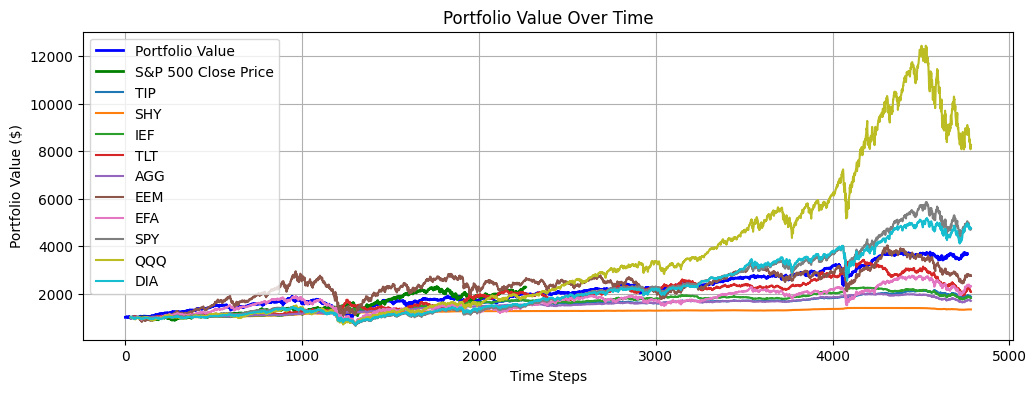

In [32]:
import matplotlib.pyplot as plt

def evaluate_policy(env, model, episodes=1):
    """Simple policy evaluation with key metrics and plots"""
    
    # Run episode
    obs, info = env.reset()
    portfolio_values = [info['portfolio_value']]
    actions_taken = []
    
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        portfolio_values.append(info['portfolio_value'])
        actions_taken.append(action)
        
        if terminated or truncated:
            break
    
    # Calculate metrics
    initial_value = portfolio_values[0]
    final_value = portfolio_values[-1]
    total_return = (final_value - initial_value) / initial_value * 100
    max_value = max(portfolio_values)

    sp500 = yf.download("^GSPC", start="2015-01-01", end="2023-12-31")
    sp500_reset = sp500.reset_index()
    sp500_aligned = sp500_reset[30:]
    sp500_Close = sp500_aligned['Close'].dropna()

    # Normalize SP500 to start at $10,000
    normalized_sp500 = sp500_Close / sp500_Close.iloc[0] * 1000

    def max_drawdown(portfolio):
        """Calculate the maximum drawdown of a portfolio."""
        peak = portfolio[0]
        max_dd = 0
        for value in portfolio:
            if value > peak:
                peak = value
            dd = (peak - value) / peak
            if dd > max_dd:
                max_dd = dd
        return max_dd
    
    max_dd = max_drawdown(portfolio_values)
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    print(f"Max Portfolio Value: ${max_value:,.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    
    # Plot portfolio value
    plt.figure(figsize=(12, 4))
    plt.plot(portfolio_values, linewidth=2, color="blue", label="Portfolio Value")
    plt.plot(normalized_sp500, linewidth=2, color="green", label="S&P 500 Close Price")

    for tick in tickers:
        tick_data = yf.download(tick, start=start, end=end)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 1000
        plt.plot(normalized_tick_data, label=tick)

    plt.title('Portfolio Value Over Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        'portfolio_values': portfolio_values,
        'total_return': total_return,
        'final_value': final_value
    }

# Usage in your notebook:
results = evaluate_policy(base_env, model)

In [33]:
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _ = env.step(action)
    env.envs[0].render()

Step: 1
Portfolio Value: $1,001.95
Cash: $168.07
TIP: 0.0000 shares @ $52.71
SHY: 0.0000 shares @ $55.69
IEF: 6.2479 shares @ $48.20
TLT: 4.8855 shares @ $43.20
AGG: 2.8301 shares @ $52.08
EEM: 8.3871 shares @ $12.20
EFA: 0.0000 shares @ $25.23
SPY: 0.0000 shares @ $76.17
QQQ: 0.0000 shares @ $31.28
DIA: 1.1053 shares @ $65.08
--------------------------------------------------
Step: 2
Portfolio Value: $1,000.00
Cash: $169.76
TIP: 0.0000 shares @ $52.71
SHY: 0.0000 shares @ $55.66
IEF: 7.2940 shares @ $48.12
TLT: 4.8855 shares @ $43.12
AGG: 1.4151 shares @ $52.09
EEM: 4.1936 shares @ $12.09
EFA: 0.0000 shares @ $24.95
SPY: 0.0000 shares @ $75.54
QQQ: 0.0000 shares @ $30.77
DIA: 2.2233 shares @ $64.85
--------------------------------------------------
Step: 3
Portfolio Value: $998.04
Cash: $181.04
TIP: 0.0000 shares @ $52.55
SHY: 0.0000 shares @ $55.62
IEF: 8.3522 shares @ $47.94
TLT: 4.8855 shares @ $42.95
AGG: 0.7075 shares @ $51.94
EEM: 2.0968 shares @ $12.09
EFA: 0.0000 shares @ $25.

In [34]:
model.save("trading_bot_multi_asset")

In [35]:
forward_data_dict = download_data(tickers, start=end, end=curr_date)
forward_env = MultiAssetTradingEnv(
    data=forward_data_dict,
    initial_balance=1000,
    lookback_window=20,
    normalize_observations=True,
    max_position_per_asset=0.5,
    buy_fraction=0.3,
    sell_fraction=0.5
)

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/656241178.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

In [36]:
def simple_forward_test(model, env):
    """
    Simple forward testing - just run the model and get basic results
    """
    # Reset environment
    obs, info = env.reset()
    
    portfolio_values = [info['portfolio_value']]
    
    # Run through all steps
    done = False
    while not done:
        # Get action from model
        action, _ = model.predict(obs, deterministic=True)
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Store portfolio value
        portfolio_values.append(info['portfolio_value'])

    plt.figure(figsize=(12, 6))
    for tick in tickers:
        tick_data = yf.download(tick, start=end, end=curr_date)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 1000
        plt.plot(normalized_tick_data, label=tick)
    
    # Calculate results
    initial_value = env.initial_balance
    final_value = portfolio_values[-1]
    total_return = ((final_value / initial_value) - 1) * 100
    
    # Plot results
    plt.plot(portfolio_values, linewidth=2, color='blue')
    plt.axhline(y=initial_value, color='red', linestyle='--', alpha=0.7, label=f'Initial: ${initial_value:,.0f}')
    plt.title('Forward Testing Results')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    
    return {
        'initial_value': initial_value,
        'final_value': final_value,
        'total_return': total_return,
        'portfolio_values': portfolio_values
    }

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_6818/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_ad

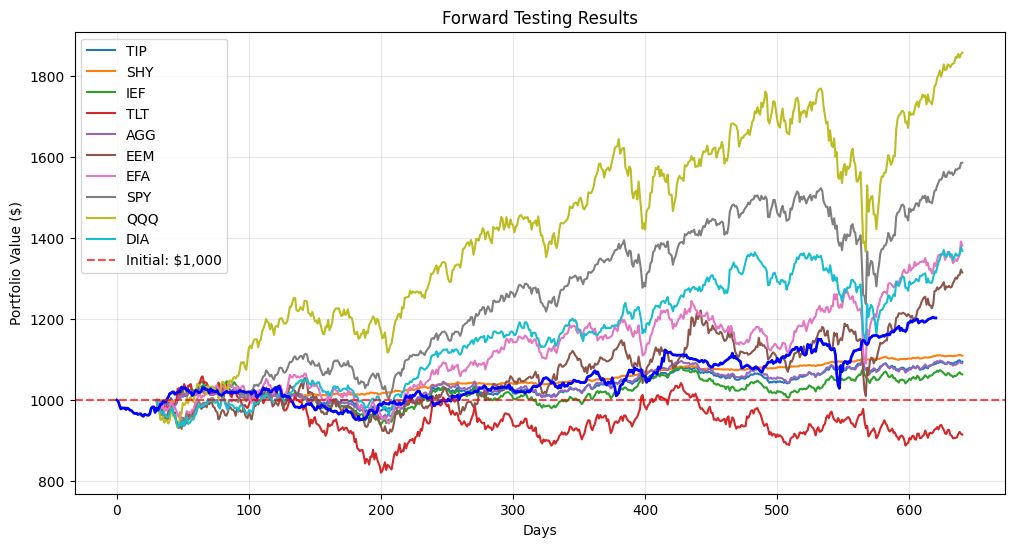

Initial Portfolio Value: $1,000.00
Final Portfolio Value: $1,202.41
Total Return: 20.24%


In [37]:
results = simple_forward_test(model, forward_env)

In [38]:
obs, info = forward_env.reset()

# Run through all steps
done = False
while not done:
    # Get action from model
    action, _ = model.predict(obs, deterministic=True)
    
    # Take step
    obs, reward, terminated, truncated, info = forward_env.step(action)
    done = terminated or truncated
    # Render environment
    forward_env.render()

Step: 1
Portfolio Value: $997.92
Cash: $490.00
TIP: 0.0000 shares @ $101.85
SHY: 0.0000 shares @ $75.00
IEF: 0.0000 shares @ $91.85
TLT: 0.0000 shares @ $98.68
AGG: 0.0000 shares @ $92.49
EEM: 7.6066 shares @ $39.20
EFA: 3.1470 shares @ $66.64
SPY: 0.0000 shares @ $402.93
QQQ: 0.0000 shares @ $306.95
DIA: 0.0000 shares @ $325.74
--------------------------------------------------
Step: 2
Portfolio Value: $987.10
Cash: $240.10
TIP: 0.0000 shares @ $100.90
SHY: 0.0000 shares @ $74.73
IEF: 0.0000 shares @ $90.87
TLT: 0.0000 shares @ $97.20
AGG: 0.0000 shares @ $91.60
EEM: 11.3562 shares @ $38.51
EFA: 4.6911 shares @ $66.02
SPY: 0.0000 shares @ $398.65
QQQ: 0.0000 shares @ $301.49
DIA: 0.0000 shares @ $324.35
--------------------------------------------------
Step: 3
Portfolio Value: $978.27
Cash: $338.70
TIP: 0.0000 shares @ $100.50
SHY: 0.0000 shares @ $74.51
IEF: 0.0000 shares @ $90.08
TLT: 0.0000 shares @ $96.48
AGG: 0.0000 shares @ $91.10
EEM: 12.8171 shares @ $37.94
EFA: 2.3456 shares